# Insurance Claims: Severity & Fraud — Exploratory Data Analysis

Dataset: `insurance_claims.csv` (1000 auto insurance claims)

Two targets analyzed on the same dataset:
- **Severity**: `total_claim_amount` (regression target)
- **Fraud**: `fraud_reported` (classification target)

## 1. Setup & Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
%matplotlib inline

In [2]:
df = pd.read_csv('insurance_claims.csv')

# Drop trailing junk column some exports of this dataset include
if '_c39' in df.columns:
    df = df.drop(columns=['_c39'])

print("Shape:", df.shape)
df.head()

Shape: (1000, 39)


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
0,328,48,521585,17-10-2014,OH,250/500,1000,1406.91,0,466132,MALE,MD,craft-repair,sleeping,husband,53300,0,25-01-2015,Single Vehicle Collision,Side Collision,Major Damage,Police,SC,Columbus,9935 4th Drive,5,1,YES,1,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y
1,228,42,342868,27-06-2006,IN,250/500,2000,1197.22,5000000,468176,MALE,MD,machine-op-inspct,reading,other-relative,0,0,21-01-2015,Vehicle Theft,?,Minor Damage,Police,VA,Riverwood,6608 MLK Hwy,8,1,?,0,0,?,5070,780,780,3510,Mercedes,E400,2007,Y
2,134,29,687698,06-09-2000,OH,100/300,2000,1413.14,5000000,430632,FEMALE,PhD,sales,board-games,own-child,35100,0,22-02-2015,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NY,Columbus,7121 Francis Lane,7,3,NO,2,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N
3,256,41,227811,25-05-1990,IL,250/500,2000,1415.74,6000000,608117,FEMALE,PhD,armed-forces,board-games,unmarried,48900,-62400,10-01-2015,Single Vehicle Collision,Front Collision,Major Damage,Police,OH,Arlington,6956 Maple Drive,5,1,?,1,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y
4,228,44,367455,06-06-2014,IL,500/1000,1000,1583.91,6000000,610706,MALE,Associate,sales,board-games,unmarried,66000,-46000,17-02-2015,Vehicle Theft,?,Minor Damage,NaN,NY,Arlington,3041 3rd Ave,20,1,NO,0,1,NO,6500,1300,650,4550,Accura,RSX,2009,N


## 2. Data Cleaning

This dataset uses `'?'` as a missing-value placeholder instead of `NaN` in three columns. We convert these to proper nulls so missing-value statistics and any later modeling steps treat them correctly.

In [3]:
print("'?' placeholder counts per column:")
for col in df.select_dtypes(include='object').columns:
    q_count = (df[col] == '?').sum()
    if q_count > 0:
        print(f"  {col}: {q_count} ({q_count/len(df)*100:.1f}%)")

df = df.replace('?', np.nan)
print("\nTrue missing values after replacement:\n", df.isnull().sum()[df.isnull().sum() > 0])

'?' placeholder counts per column:
  collision_type: 178 (17.8%)
  property_damage: 360 (36.0%)
  police_report_available: 343 (34.3%)

True missing values after replacement:
 collision_type             178
authorities_contacted       91
property_damage            360
police_report_available    343
dtype: int64


In [4]:
# Clean binary encoding of the fraud target for correlation/modeling use
df['fraud_label'] = df['fraud_reported'].map({'Y': 1, 'N': 0})

## 3. Severity EDA — `total_claim_amount`

In [5]:
print(df['total_claim_amount'].describe())

count      1000.00000
mean      52761.94000
std       26401.53319
min         100.00000
25%       41812.50000
50%       58055.00000
75%       70592.50000
max      114920.00000
Name: total_claim_amount, dtype: float64


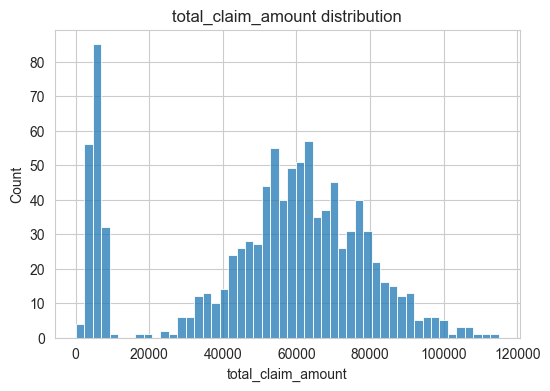

In [6]:
plt.figure(figsize=(6, 4))
sns.histplot(df['total_claim_amount'], bins=50)
plt.title('total_claim_amount distribution')
plt.savefig('severity_distribution.png', dpi=100)
plt.show()
plt.close()

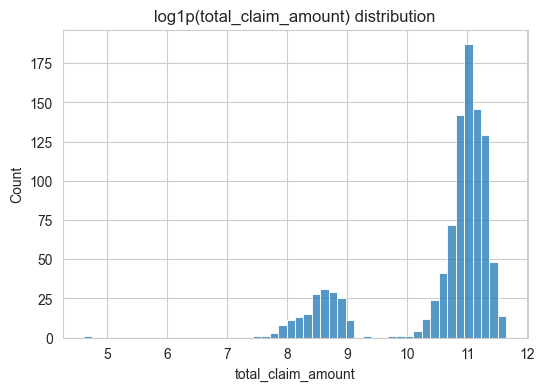

Skewness (raw): -0.594581988510234
Skewness (log1p): -1.6605098039725132


In [7]:
plt.figure(figsize=(6, 4))
sns.histplot(np.log1p(df['total_claim_amount']), bins=50)
plt.title('log1p(total_claim_amount) distribution')
plt.savefig('severity_distribution_log.png', dpi=100)
plt.show()
plt.close()

print("Skewness (raw):", df['total_claim_amount'].skew())
print("Skewness (log1p):", np.log1p(df['total_claim_amount']).skew())

**Finding:** The raw distribution is bimodal, not simply right-skewed — log-transforming actually makes skewness *worse* (-0.59 to -1.66). This rules out a naive log-transform and points to two underlying populations of claims rather than one skewed distribution.

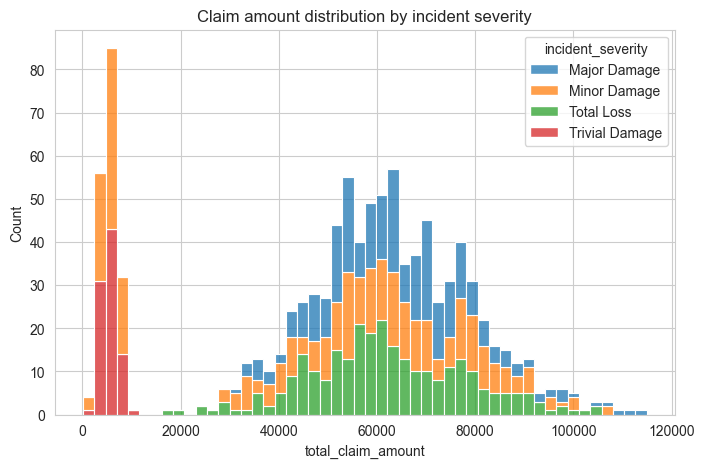

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='total_claim_amount', hue='incident_severity', bins=50, multiple='stack')
plt.title('Claim amount distribution by incident severity')
plt.savefig('severity_by_incidenttype.png', dpi=100)
plt.show()
plt.close()

In [9]:
minor_high = df[(df['incident_severity'] == 'Minor Damage') & (df['total_claim_amount'] > 30000)]
minor_low = df[(df['incident_severity'] == 'Minor Damage') & (df['total_claim_amount'] <= 30000)]

print("Minor Damage, high claim amount:", len(minor_high))
print("Minor Damage, low claim amount:", len(minor_low))

print("\nHigh-amount Minor Damage breakdown:\n", minor_high[['injury_claim','property_claim','vehicle_claim']].mean())
print("\nLow-amount Minor Damage breakdown:\n", minor_low[['injury_claim','property_claim','vehicle_claim']].mean())

print("\nFraud rate - high amount Minor Damage:", minor_high['fraud_label'].mean())
print("Fraud rate - low amount Minor Damage:", minor_low['fraud_label'].mean())

print("\n", minor_high[['number_of_vehicles_involved','witnesses','bodily_injuries']].mean())
print("\n", minor_low[['number_of_vehicles_involved','witnesses','bodily_injuries']].mean())

Minor Damage, high claim amount: 263
Minor Damage, low claim amount: 91

High-amount Minor Damage breakdown:
 injury_claim       9167.490494
property_claim     8726.577947
vehicle_claim     45401.787072
dtype: float64

Low-amount Minor Damage breakdown:
 injury_claim       852.637363
property_claim     910.000000
vehicle_claim     4530.769231
dtype: float64

Fraud rate - high amount Minor Damage: 0.10646387832699619
Fraud rate - low amount Minor Damage: 0.10989010989010989

 number_of_vehicles_involved    1.988593
witnesses                      1.384030
bodily_injuries                0.992395
dtype: float64

 number_of_vehicles_involved    1.043956
witnesses                      1.483516
bodily_injuries                0.967033
dtype: float64


In [10]:
print(df.groupby('number_of_vehicles_involved')['total_claim_amount'].mean())
print(df.groupby('number_of_vehicles_involved')['vehicle_claim'].mean())
print("\nCorrelation - vehicles involved vs total claim:",
      df['number_of_vehicles_involved'].corr(df['total_claim_amount']))

number_of_vehicles_involved
1    46361.497418
2    64053.000000
3    61442.988827
4    61539.677419
Name: total_claim_amount, dtype: float64
number_of_vehicles_involved
1    33437.194492
2    45381.333333
3    44083.379888
4    43827.419355
Name: vehicle_claim, dtype: float64

Correlation - vehicles involved vs total claim: 0.2742776826593702


**Findings:**
- `incident_severity` explains most, but not all, of the bimodal shape — "Minor Damage" claims split into two distinct cost groups
- The split is explained by `number_of_vehicles_involved`: multi-vehicle "Minor Damage" incidents rack up far higher `vehicle_claim` totals (~45k vs ~4.5k) since repair costs stack across multiple cars
- This is *not* a fraud signal — fraud rate is nearly identical between the high- and low-amount Minor Damage groups (10.6% vs 11.0%) — tested and rejected
- The vehicle-count effect is a **threshold effect, not linear**: 1 vehicle leads to ~46k avg claim, 2+ vehicles leads to ~61-64k, but 2 vs 3 vs 4 vehicles barely differs. Correlation is moderate (0.27) because Pearson assumes linearity, which doesn't hold here

**Feature engineering implication:** build a binary `multi_vehicle_incident` flag (1 vehicle vs. 2+) as well as keeping `incident_severity` interacted with `number_of_vehicles_involved` as a signal for the severity model.

In [11]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_with_severity = df[numeric_cols].corr()['total_claim_amount'].sort_values(ascending=False)
print("Numeric correlation with total_claim_amount:\n", corr_with_severity)

Numeric correlation with total_claim_amount:
 total_claim_amount             1.000000
vehicle_claim                  0.982773
property_claim                 0.810686
injury_claim                   0.805025
number_of_vehicles_involved    0.274278
incident_hour_of_the_day       0.217702
fraud_label                    0.163651
age                            0.069863
months_as_customer             0.062108
bodily_injuries                0.047093
policy_deductable              0.022839
capital-gains                  0.015980
policy_annual_premium          0.009094
witnesses                     -0.011114
policy_number                 -0.018009
insured_zip                   -0.033873
auto_year                     -0.035781
capital-loss                  -0.036060
umbrella_limit                -0.040344
Name: total_claim_amount, dtype: float64


## 4. Fraud EDA — `fraud_reported`

fraud_reported
N    753
Y    247
Name: count, dtype: int64
fraud_reported
N    75.3
Y    24.7
Name: proportion, dtype: float64


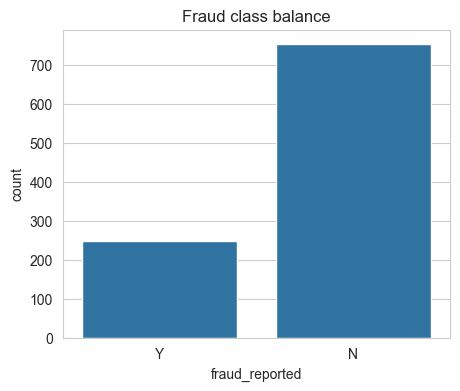

In [12]:
print(df['fraud_reported'].value_counts())
print(df['fraud_reported'].value_counts(normalize=True) * 100)

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='fraud_reported')
plt.title('Fraud class balance')
plt.savefig('fraud_balance.png', dpi=100)
plt.show()
plt.close()

**Note:** 24.7% fraud / 75.3% non-fraud — imbalanced but not extreme. Class weighting or light resampling should be enough; heavy SMOTE is probably unnecessary.

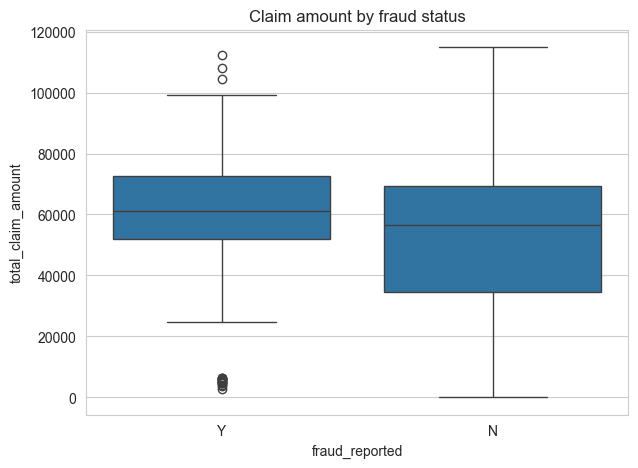

                        mean   median           std  count
fraud_reported                                            
N               50288.605578  56520.0  27575.191379    753
Y               60302.105263  61290.0  20746.279567    247

                injury_claim  property_claim  vehicle_claim
fraud_reported                                             
N                7179.229748     7018.884462   36090.491368
Y                8208.340081     8560.121457   43533.643725


In [13]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='fraud_reported', y='total_claim_amount')
plt.title('Claim amount by fraud status')
plt.savefig('claimamount_vs_fraud.png', dpi=100)
plt.show()
plt.close()

print(df.groupby('fraud_reported')['total_claim_amount'].agg(['mean', 'median', 'std', 'count']))
print()
print(df.groupby('fraud_reported')[['injury_claim', 'property_claim', 'vehicle_claim']].mean())

In [14]:
corr_with_fraud = df[numeric_cols].corr()['fraud_label'].sort_values(ascending=False)
print("Numeric correlation with fraud_label:\n", corr_with_fraud)

Numeric correlation with fraud_label:
 fraud_label                    1.000000
vehicle_claim                  0.170049
total_claim_amount             0.163651
property_claim                 0.137835
injury_claim                   0.090975
umbrella_limit                 0.058622
number_of_vehicles_involved    0.051839
witnesses                      0.049497
bodily_injuries                0.033877
months_as_customer             0.020544
insured_zip                    0.019368
policy_deductable              0.014817
age                            0.012143
auto_year                      0.007928
incident_hour_of_the_day       0.004316
policy_annual_premium         -0.014480
capital-loss                  -0.014863
capital-gains                 -0.019173
policy_number                 -0.029443
Name: fraud_label, dtype: float64


**Finding:** No numeric feature correlates with fraud above 0.17 (vehicle_claim). Numeric features alone are weak predictors of fraud — the real signal is categorical (see below).

In [15]:
print("Fraud rate by incident_severity:\n",
      df.groupby('incident_severity')['fraud_label'].mean().sort_values(ascending=False))
print("\nCounts:\n", df.groupby('incident_severity')['fraud_label'].count())

Fraud rate by incident_severity:
 incident_severity
Major Damage      0.605072
Total Loss        0.128571
Minor Damage      0.107345
Trivial Damage    0.066667
Name: fraud_label, dtype: float64

Counts:
 incident_severity
Major Damage      276
Minor Damage      354
Total Loss        280
Trivial Damage     90
Name: fraud_label, dtype: int64


**Headline finding:** `incident_severity` is by far the strongest fraud predictor in this dataset:

| incident_severity | fraud rate |
|---|---|
| Major Damage | **60.5%** |
| Total Loss | 12.9% |
| Minor Damage | 10.7% |
| Trivial Damage | 6.7% |

This single category dwarfs every other signal tested below (which sit in a 17-30% band) and every numeric correlation (max 0.17).

**Caveat to flag in the report:** `incident_severity` is assessed by an adjuster after the incident, and adjusters likely scrutinize large claims more heavily — meaning some of this association could reflect detection intensity rather than a true causal driver of fraud. Worth treating as a strong feature, but not over-claiming causality.

In [16]:
for col in ['incident_type', 'collision_type', 'authorities_contacted', 'insured_relationship', 'insured_occupation']:
    print(f"Fraud rate by {col}:")
    print(df.groupby(col)['fraud_label'].mean().sort_values(ascending=False))
    print()

Fraud rate by incident_type:
incident_type
Single Vehicle Collision    0.290323
Multi-vehicle Collision     0.272076
Parked Car                  0.095238
Vehicle Theft               0.085106
Name: fraud_label, dtype: float64

Fraud rate by collision_type:
collision_type
Rear Collision     0.311644
Front Collision    0.275591
Side Collision     0.253623
Name: fraud_label, dtype: float64

Fraud rate by authorities_contacted:
authorities_contacted
Other        0.318182
Ambulance    0.290816
Fire         0.269058
Police       0.208904
Name: fraud_label, dtype: float64

Fraud rate by insured_relationship:
insured_relationship
other-relative    0.293785
wife              0.270968
not-in-family     0.258621
unmarried         0.241135
own-child         0.213115
husband           0.205882
Name: fraud_label, dtype: float64

Fraud rate by insured_occupation:
insured_occupation
exec-managerial      0.368421
farming-fishing      0.301887
craft-repair         0.297297
transport-moving     0.291667
t

In [17]:
# Tested and rejected: state mismatch as a fraud signal
df['state_mismatch'] = (df['policy_state'] != df['incident_state']).astype(int)
print(df.groupby('state_mismatch')['fraud_label'].mean())
print(df['state_mismatch'].value_counts())

state_mismatch
0    0.666667
1    0.243189
Name: fraud_label, dtype: float64
state_mismatch
1    991
0      9
Name: count, dtype: int64


**Tested and rejected:** `state_mismatch` is not a usable feature. Only 9 of 1000 rows have `policy_state == incident_state` — the dataset's policies span just 3 states while incidents span 7, so "mismatch" is the default for 99.1% of records. The apparent 66.7% fraud rate in the "match" group comes from just 9 rows and is noise, not signal. Dropped from the feature engineering plan.

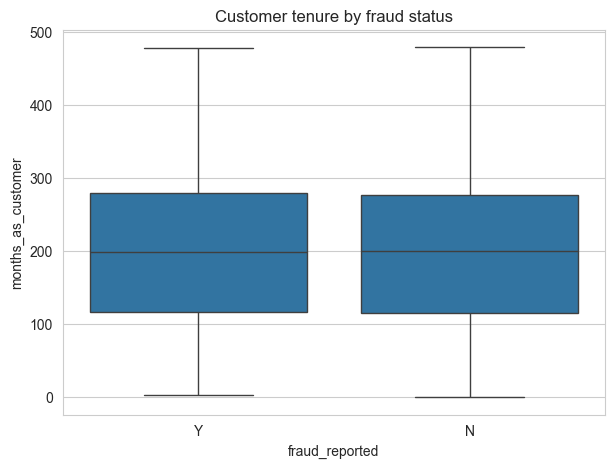

                      mean  median
fraud_reported                    
N               202.600266   200.0
Y               208.080972   199.0


In [18]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='fraud_reported', y='months_as_customer')
plt.title('Customer tenure by fraud status')
plt.savefig('tenure_vs_fraud.png', dpi=100)
plt.show()
plt.close()

print(df.groupby('fraud_reported')['months_as_customer'].agg(['mean', 'median']))

In [19]:
print("Fraud rate by witnesses count:\n", df.groupby('witnesses')['fraud_label'].mean())
print("\nFraud rate by police_report_available:\n", df.groupby('police_report_available')['fraud_label'].mean())

Fraud rate by witnesses count:
 witnesses
0    0.200803
1    0.244186
2    0.296000
3    0.246914
Name: fraud_label, dtype: float64

Fraud rate by police_report_available:
 police_report_available
NO     0.250729
YES    0.229299
Name: fraud_label, dtype: float64


**Tested and rejected:**
- Tenure (`months_as_customer`): no meaningful difference between fraud (208.1) and non-fraud (202.6) — the "new customer commits fraud" pattern does not hold in this data
- Witnesses count and police report availability: both flat across fraud/non-fraud, no usable signal

## 5. Full Correlation Heatmap

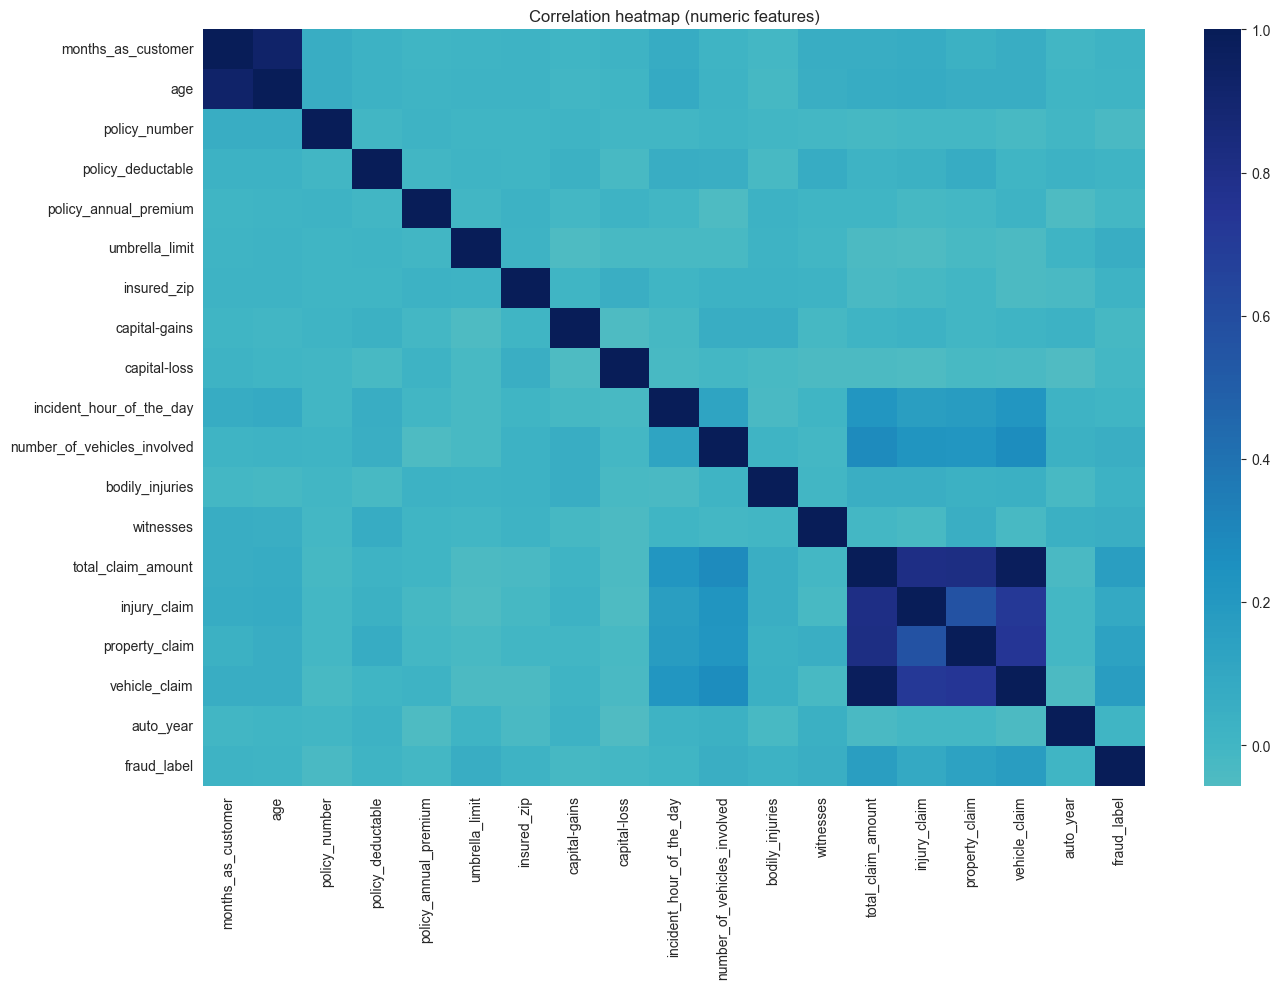

In [22]:
plt.figure(figsize=(14, 10))
sns.heatmap(df[numeric_cols].corr(), annot=False, cmap='YlGnBu', center=0)
plt.title('Correlation heatmap (numeric features)')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100)
plt.show()
plt.close()

## 6. Summary of EDA Findings

**Severity (`total_claim_amount`):**
- Bimodal distribution driven primarily by `incident_severity`; log-transform is not appropriate
- `number_of_vehicles_involved` is a secondary driver with a threshold effect (1 vs. 2+ vehicles), not linear
- Plan: build `multi_vehicle_incident` flag plus `incident_severity` interaction features for the severity model

**Fraud (`fraud_reported`):**
- Heavily concentrated signal: `incident_severity` (Major Damage = 60.5% fraud vs. 7-13% elsewhere) is the dominant predictor, with a caveat about possible detection-intensity confound
- Secondary categorical signals (incident_type, collision_type, authorities_contacted, occupation, relationship) are mild (17-30% range)
- All numeric features are weak fraud predictors (max correlation 0.17)
- Rejected hypotheses: state mismatch (data artifact), tenure, witnesses, police report availability

**Next step:** Feature engineering for both models, incorporating `incident_severity`, `multi_vehicle_incident`, and the interaction terms identified above.